# Radiation Timestep Calibration: Volume-Matching Method

This notebook calculates the correct simulation timestep at which to apply radiation,
by matching the simulated tumour volume to the Day 12 in vivo tumour volume from
Romano et al. (2021).

**Problem:** Tanaya's model applies radiation at timestep 200 and maps it to Day 12,
but provides no formal derivation for this choice.

**Method:** We run/load a Control (no radiation) simulation, convert tumour cell counts
to tumour volume (% of brain), and find the timestep where this volume matches the
Day 12 in vivo measurement from Romano et al.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

## 1. In Vivo Reference Data (Romano et al., 2021)

From Romano et al. Figure 1b, the Control group tumour volumes at key timepoints
were approximately (read from the graph):

| Day | Tumour Volume (% brain) |
|-----|------------------------|
| 10  | ~1-2%                  |
| 12  | ~3-5%  (radiation day) |
| 15  | ~8-12%                 |
| 20  | ~15-25%                |
| 25  | ~30-50%                |

**Adjust the value below** based on your best reading of the Romano et al. figure.
The Control group tumour volume on Day 12 is the target.

In [2]:
# ========== CONFIGURATION ==========

# In vivo tumour volume (% of brain) on Day 12 from Romano et al. (2021)
# Read this value from their Figure 1b, Control group at Day 12
IN_VIVO_DAY12_VOLUME_PERCENT = 4.0  # Adjust based on your reading of the figure

# Grid dimensions (from Main.java)
GRID_X = 100
GRID_Y = 100
TOTAL_GRID_CELLS = GRID_X * GRID_Y  # 10,000

# Voxel volume assumption (from Tanaya's report, page 30)
VOXEL_VOLUME_MM3 = 0.001  # 100um x 100um x 100um = 0.001 mm^3

# Fischer rat brain volume (from Tanaya's report)
RAT_BRAIN_VOLUME_MM3 = 2000  # mm^3

print(f"Target in vivo Day 12 volume: {IN_VIVO_DAY12_VOLUME_PERCENT}% of brain")
print(f"Grid capacity: {TOTAL_GRID_CELLS} cells")
print(f"Max simulatable volume: {(TOTAL_GRID_CELLS * VOXEL_VOLUME_MM3 / RAT_BRAIN_VOLUME_MM3) * 100:.2f}% of brain")

Target in vivo Day 12 volume: 4.0% of brain
Grid capacity: 10000 cells
Max simulatable volume: 0.50% of brain


## 2. Load Control Simulation Data

Load the CSV output from Control (no radiation) scenario runs.

In [3]:
# Path to Control scenario CSV files
control_dir = "HALModeling2024Outs/ScenarioControl/"
csv_files = sorted(glob.glob(os.path.join(control_dir, "TrialRunCounts_*.csv")))

print(f"Found {len(csv_files)} Control trial(s):")
for f in csv_files:
    print(f"  {os.path.basename(f)}")

if len(csv_files) == 0:
    print("\nNo Control CSVs found. You need to run the simulation first:")
    print('  Set scenario = "Control" in Main.java and run the simulation.')
    print("  Or change control_dir above to point to your CSV files.")

Found 10 Control trial(s):
  TrialRunCounts_20260422_173059.csv
  TrialRunCounts_20260422_173108.csv
  TrialRunCounts_20260422_173115.csv
  TrialRunCounts_20260422_173123.csv
  TrialRunCounts_20260422_173130.csv
  TrialRunCounts_20260422_173138.csv
  TrialRunCounts_20260422_173146.csv
  TrialRunCounts_20260422_173153.csv
  TrialRunCounts_20260422_173200.csv
  TrialRunCounts_20260422_173208.csv


In [4]:
# Load all Control trials into a list of DataFrames
control_trials = []
for f in csv_files:
    df = pd.read_csv(f)
    control_trials.append(df)
    print(f"{os.path.basename(f)}: {len(df)} timesteps, "
          f"final TumorCells = {df['TumorCells'].iloc[-1]}")

# Use the first trial for initial analysis
df_control = control_trials[0]
df_control.head(10)

TrialRunCounts_20260422_173059.csv: 541 timesteps, final TumorCells = 6556
TrialRunCounts_20260422_173108.csv: 541 timesteps, final TumorCells = 6194
TrialRunCounts_20260422_173115.csv: 541 timesteps, final TumorCells = 6600
TrialRunCounts_20260422_173123.csv: 541 timesteps, final TumorCells = 6444
TrialRunCounts_20260422_173130.csv: 541 timesteps, final TumorCells = 6768
TrialRunCounts_20260422_173138.csv: 541 timesteps, final TumorCells = 6501
TrialRunCounts_20260422_173146.csv: 541 timesteps, final TumorCells = 5995
TrialRunCounts_20260422_173153.csv: 541 timesteps, final TumorCells = 6044
TrialRunCounts_20260422_173200.csv: 541 timesteps, final TumorCells = 6134
TrialRunCounts_20260422_173208.csv: 541 timesteps, final TumorCells = 5617


,Timestep,Lymphocytes,TriggeringCells,TumorCells,TumorCellsRad,DoomedCells,DoomedCellsRad,DoomedCellsImm,Lymphocytes DieProb,Tumor DieProbRad,...,TumorClone2Rad,Clone0DieProbRad,Clone0DieProbImm,Clone0DivProb,Clone1DieProbRad,Clone1DieProbImm,Clone1DivProb,Clone2DieProbRad,Clone2DieProbImm,Clone2DivProb
0,0,0,500,3,0,0,0,0,0.045,0.0,...,0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000
1,1,0,499,4,0,0,0,0,0.045,0.0,...,0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000
2,2,0,498,7,0,0,0,0,0.045,0.0,...,0,0.0,0.000000,0.217000,0.0,0.000000,0.238700,0.0,0.000000,0.206150
3,3,1,497,10,0,0,0,0,0.045,0.0,...,0,0.0,0.000000,0.217000,0.0,0.000000,0.238700,0.0,0.000000,0.206150
4,4,2,496,12,0,0,0,0,0.045,0.0,...,0,0.0,0.040344,0.208245,0.0,0.044379,0.229070,0.0,0.012103,0.197833
5,5,3,495,15,0,0,0,0,0.045,0.0,...,0,0.0,0.042812,0.207710,0.0,0.047093,0.228481,0.0,0.012843,0.197324
6,6,4,494,19,0,0,0,0,0.045,0.0,...,0,0.0,0.039545,0.208419,0.0,0.043500,0.229261,0.0,0.011864,0.197998
7,7,6,493,21,0,2,0,2,0.045,0.0,...,0,0.0,0.035000,0.209405,0.0,0.038500,0.230346,0.0,0.010500,0.198935
8,8,7,492,25,0,2,0,2,0.045,0.0,...,0,0.0,0.033554,0.209719,0.0,0.036910,0.230691,0.0,0.010066,0.199233
9,9,8,491,31,0,3,0,3,0.045,0.0,...,0,0.0,0.030166,0.210454,0.0,0.033183,0.231499,0.0,0.009050,0.199931


## 3. Convert Cell Count to Tumour Volume (%)

Using Tanaya's formula (report page 30):

$$\text{Tumour Volume (\%)} = \frac{\text{Cell Count} \times 0.001}{2000} \times 100$$

In [5]:
def cell_count_to_volume_percent(cell_count):
    """Convert ABM cell count to tumour volume as % of rat brain."""
    return (cell_count * VOXEL_VOLUME_MM3 / RAT_BRAIN_VOLUME_MM3) * 100

def volume_percent_to_cell_count(volume_percent):
    """Convert tumour volume (% of brain) back to ABM cell count."""
    return (volume_percent / 100) * RAT_BRAIN_VOLUME_MM3 / VOXEL_VOLUME_MM3

# Add volume column to the control data
df_control['TumourVolume_pct'] = cell_count_to_volume_percent(df_control['TumorCells'])

# What cell count corresponds to the Day 12 in vivo volume?
target_cell_count = volume_percent_to_cell_count(IN_VIVO_DAY12_VOLUME_PERCENT)
print(f"Target Day 12 volume: {IN_VIVO_DAY12_VOLUME_PERCENT}% of brain")
print(f"Equivalent ABM cell count: {target_cell_count:,.0f} cells")
print(f"Grid occupancy at target: {target_cell_count/TOTAL_GRID_CELLS*100:.1f}%")

if target_cell_count > TOTAL_GRID_CELLS:
    print(f"\nWARNING: Target ({target_cell_count:,.0f}) exceeds grid capacity ({TOTAL_GRID_CELLS:,}).")
    print("The grid is too small to represent this volume directly.")
    print("We will use grid-fraction matching instead (see Section 4b).")

Target Day 12 volume: 4.0% of brain
Equivalent ABM cell count: 80,000 cells
Grid occupancy at target: 800.0%

The grid is too small to represent this volume directly.
We will use grid-fraction matching instead (see Section 4b).


## 4. Find the Matching Timestep

### 4a. Direct Volume Matching
If the target cell count fits within the grid, find when the tumour first reaches it.

### 4b. Proportional Grid-Fraction Matching
If the target exceeds grid capacity, we match based on the **fraction of available space**
occupied by the tumour. This accounts for the fact that our 10,000-cell grid is a
scaled-down representation of the real brain.

In [6]:
# ---- METHOD A: Direct volume matching (if target fits in grid) ----
if target_cell_count <= TOTAL_GRID_CELLS:
    match_rows = df_control[df_control['TumorCells'] >= target_cell_count]
    if len(match_rows) > 0:
        matched_timestep_A = match_rows['Timestep'].iloc[0]
        matched_cells_A = match_rows['TumorCells'].iloc[0]
        matched_vol_A = cell_count_to_volume_percent(matched_cells_A)
        print(f"METHOD A - Direct Volume Match:")
        print(f"  Timestep: {matched_timestep_A}")
        print(f"  Tumour cells: {matched_cells_A}")
        print(f"  Tumour volume: {matched_vol_A:.4f}% of brain")
    else:
        print("Tumour never reached target volume in this simulation.")
        matched_timestep_A = None
else:
    print(f"Target cell count ({target_cell_count:,.0f}) exceeds grid ({TOTAL_GRID_CELLS:,}).")
    print("Skipping Method A, using Method B instead.")
    matched_timestep_A = None

print()

Target cell count (80,000) exceeds grid (10,000).
Skipping Method A, using Method B instead.



In [7]:
# ---- METHOD B: Grid-fraction matching ----
# In vivo: what fraction of the brain does the tumour occupy at Day 12?
in_vivo_fraction = IN_VIVO_DAY12_VOLUME_PERCENT / 100.0

# In ABM: what cell count represents the same fraction of the grid?
target_grid_fraction = in_vivo_fraction * TOTAL_GRID_CELLS

print(f"METHOD B - Grid-Fraction Matching:")
print(f"  In vivo tumour fraction at Day 12: {in_vivo_fraction*100:.1f}% of brain")
print(f"  Equivalent grid fraction: {target_grid_fraction:.0f} / {TOTAL_GRID_CELLS} cells")
print(f"  ({in_vivo_fraction*100:.1f}% of grid)")
print()

match_rows_B = df_control[df_control['TumorCells'] >= target_grid_fraction]
if len(match_rows_B) > 0:
    matched_timestep_B = match_rows_B['Timestep'].iloc[0]
    matched_cells_B = match_rows_B['TumorCells'].iloc[0]
    print(f"  Matched timestep: {matched_timestep_B}")
    print(f"  Tumour cells at match: {matched_cells_B}")
    print(f"  Grid occupancy: {matched_cells_B/TOTAL_GRID_CELLS*100:.1f}%")
else:
    print("  Tumour never reached target grid fraction.")
    matched_timestep_B = None

METHOD B - Grid-Fraction Matching:
  In vivo tumour fraction at Day 12: 4.0% of brain
  Equivalent grid fraction: 400 / 10000 cells
  (4.0% of grid)

  Matched timestep: 53
  Tumour cells at match: 408
  Grid occupancy: 4.1%


In [8]:
# ---- Select the best method ----
if matched_timestep_A is not None:
    calibrated_timestep = matched_timestep_A
    method_used = "A (Direct Volume)"
elif matched_timestep_B is not None:
    calibrated_timestep = matched_timestep_B
    method_used = "B (Grid-Fraction)"
else:
    calibrated_timestep = None
    method_used = "None - tumour did not reach target"

print("=" * 50)
print(f"CALIBRATED RADIATION TIMESTEP: {calibrated_timestep}")
print(f"Method used: {method_used}")
print(f"Tanaya's original choice: 200")
if calibrated_timestep is not None:
    print(f"Difference: {calibrated_timestep - 200} timesteps")
print("=" * 50)

CALIBRATED RADIATION TIMESTEP: 53
Method used: B (Grid-Fraction)
Tanaya's original choice: 200
Difference: -147 timesteps


## 5. Visualisation: Tumour Growth with Volume-Match Point

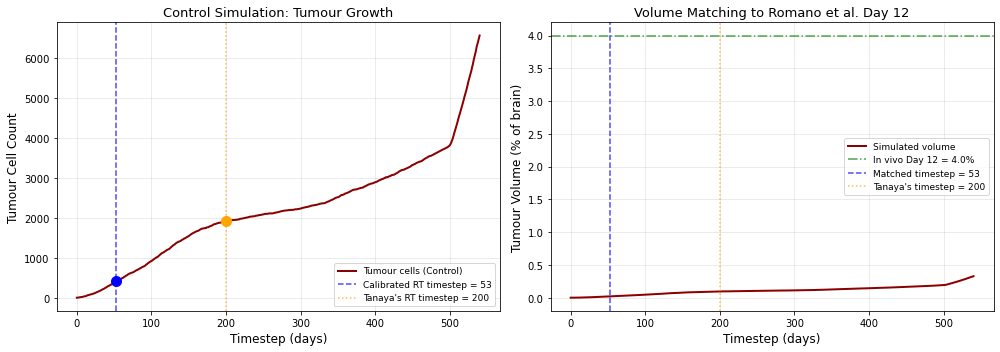

Figure saved to HALModeling2024Outs/radiation_timestep_calibration.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left plot: Tumour cell count over time ---
ax1 = axes[0]
ax1.plot(df_control['Timestep'], df_control['TumorCells'],
         color='darkred', linewidth=2, label='Tumour cells (Control)')

# Mark the calibrated timestep
if calibrated_timestep is not None:
    match_row = df_control[df_control['Timestep'] == calibrated_timestep]
    if len(match_row) > 0:
        ax1.axvline(x=calibrated_timestep, color='blue', linestyle='--', alpha=0.7,
                    label=f'Calibrated RT timestep = {calibrated_timestep}')
        ax1.scatter(calibrated_timestep, match_row['TumorCells'].iloc[0],
                    color='blue', s=100, zorder=5)

# Mark Tanaya's original timestep 200
ax1.axvline(x=200, color='orange', linestyle=':', alpha=0.7,
            label="Tanaya's RT timestep = 200")
row_200 = df_control[df_control['Timestep'] == 200]
if len(row_200) > 0:
    ax1.scatter(200, row_200['TumorCells'].iloc[0],
                color='orange', s=100, zorder=5)

ax1.set_xlabel('Timestep (days)', fontsize=12)
ax1.set_ylabel('Tumour Cell Count', fontsize=12)
ax1.set_title('Control Simulation: Tumour Growth', fontsize=13)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Right plot: Tumour volume (% brain) with target line ---
ax2 = axes[1]
ax2.plot(df_control['Timestep'], df_control['TumourVolume_pct'],
         color='darkred', linewidth=2, label='Simulated volume')

# Target volume line
ax2.axhline(y=IN_VIVO_DAY12_VOLUME_PERCENT, color='green', linestyle='-.',
            alpha=0.7, label=f'In vivo Day 12 = {IN_VIVO_DAY12_VOLUME_PERCENT}%')

if calibrated_timestep is not None:
    ax2.axvline(x=calibrated_timestep, color='blue', linestyle='--', alpha=0.7,
                label=f'Matched timestep = {calibrated_timestep}')

ax2.axvline(x=200, color='orange', linestyle=':', alpha=0.7,
            label="Tanaya's timestep = 200")

ax2.set_xlabel('Timestep (days)', fontsize=12)
ax2.set_ylabel('Tumour Volume (% of brain)', fontsize=12)
ax2.set_title('Volume Matching to Romano et al. Day 12', fontsize=13)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('HALModeling2024Outs/radiation_timestep_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to HALModeling2024Outs/radiation_timestep_calibration.png")

## 6. Per-Clone Breakdown at the Calibrated Timestep

In [10]:
if calibrated_timestep is not None:
    row = df_control[df_control['Timestep'] == calibrated_timestep].iloc[0]
    total = row['TumorCells']

    print(f"Tumour state at calibrated timestep {calibrated_timestep}:")
    print(f"  Total tumour cells: {int(total)}")
    print(f"  Grid occupancy:     {total/TOTAL_GRID_CELLS*100:.1f}%")
    print(f"  Volume (% brain):   {cell_count_to_volume_percent(total):.4f}%")
    print()

    clone_names = ['Baseline', 'Proliferative', 'InvasiveResistant']
    clone_cols = ['TumorClone0', 'TumorClone1', 'TumorClone2']

    print(f"  {'Clone':<22} {'Count':>6} {'Fraction':>10}")
    print(f"  {'-'*22} {'-'*6} {'-'*10}")
    for name, col in zip(clone_names, clone_cols):
        count = int(row[col])
        frac = count / total * 100 if total > 0 else 0
        print(f"  {name:<22} {count:>6} {frac:>9.1f}%")

Tumour state at calibrated timestep 53:
  Total tumour cells: 408
  Grid occupancy:     4.1%
  Volume (% brain):   0.0204%

  Clone                   Count   Fraction
  ---------------------- ------ ----------
  Baseline                   80      19.6%
  Proliferative             184      45.1%
  InvasiveResistant         144      35.3%


## 7. Multi-Trial Analysis (if multiple Control runs available)

In [11]:
if len(control_trials) > 1:
    matched_timesteps = []
    for i, df in enumerate(control_trials):
        match = df[df['TumorCells'] >= target_grid_fraction]
        if len(match) > 0:
            ts = match['Timestep'].iloc[0]
            matched_timesteps.append(ts)
            print(f"  Trial {i+1}: matched at timestep {ts} "
                  f"(cells = {match['TumorCells'].iloc[0]})")
        else:
            print(f"  Trial {i+1}: tumour did not reach target")

    if matched_timesteps:
        mean_ts = np.mean(matched_timesteps)
        std_ts = np.std(matched_timesteps)
        print(f"\n  Mean matched timestep: {mean_ts:.1f} +/- {std_ts:.1f}")
        print(f"  Range: [{min(matched_timesteps)}, {max(matched_timesteps)}]")
        print(f"  Tanaya's choice (200) is within range: "
              f"{min(matched_timesteps) <= 200 <= max(matched_timesteps)}")
else:
    print("Only 1 Control trial available.")
    print("Run more Control trials for a robust calibration.")
    print("(Set scenario = 'Control' in Main.java and run multiple times)")

  Trial 1: matched at timestep 53 (cells = 408)
  Trial 2: matched at timestep 61 (cells = 406)
  Trial 3: matched at timestep 60 (cells = 407)
  Trial 4: matched at timestep 56 (cells = 402)
  Trial 5: matched at timestep 58 (cells = 404)
  Trial 6: matched at timestep 57 (cells = 403)
  Trial 7: matched at timestep 61 (cells = 402)
  Trial 8: matched at timestep 74 (cells = 410)
  Trial 9: matched at timestep 57 (cells = 403)
  Trial 10: matched at timestep 60 (cells = 406)

  Mean matched timestep: 59.7 +/- 5.3
  Range: [53, 74]
  Tanaya's choice (200) is within range: False


## 8. Sensitivity: How Does the Timestep Change with Different Day 12 Estimates?

In [12]:
# Test a range of possible Day 12 in vivo volumes
test_volumes = [2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0]

print(f"{'Day 12 Volume (%)':<20} {'Target Cells':>14} {'Matched Timestep':>18}")
print(f"{'-'*20} {'-'*14} {'-'*18}")

sensitivity_results = []
for vol in test_volumes:
    fraction = vol / 100.0
    target = fraction * TOTAL_GRID_CELLS
    match = df_control[df_control['TumorCells'] >= target]
    if len(match) > 0:
        ts = match['Timestep'].iloc[0]
        sensitivity_results.append((vol, target, ts))
        print(f"{vol:<20.1f} {target:>14.0f} {ts:>18}")
    else:
        sensitivity_results.append((vol, target, None))
        print(f"{vol:<20.1f} {target:>14.0f} {'Not reached':>18}")

Day 12 Volume (%)      Target Cells   Matched Timestep
-------------------- -------------- ------------------
2.0                             200                 34
3.0                             300                 43
4.0                             400                 53
5.0                             500                 62
6.0                             600                 70
8.0                             800                 92
10.0                           1000                106


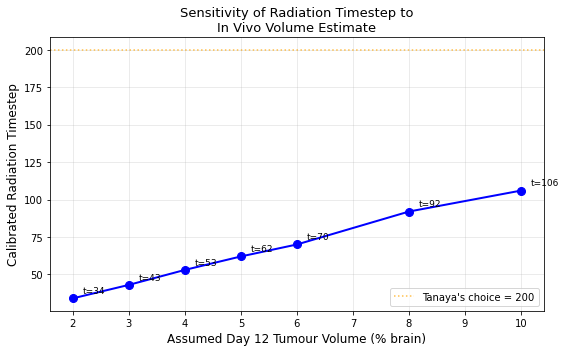

Figure saved to HALModeling2024Outs/radiation_timestep_sensitivity.png


In [13]:
# Plot sensitivity
valid = [(v, t) for v, _, t in sensitivity_results if t is not None]
if valid:
    vols, timesteps = zip(*valid)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(vols, timesteps, 'bo-', markersize=8, linewidth=2)
    ax.axhline(y=200, color='orange', linestyle=':', alpha=0.7,
               label="Tanaya's choice = 200")
    ax.set_xlabel('Assumed Day 12 Tumour Volume (% brain)', fontsize=12)
    ax.set_ylabel('Calibrated Radiation Timestep', fontsize=12)
    ax.set_title('Sensitivity of Radiation Timestep to\nIn Vivo Volume Estimate',
                 fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # Annotate each point
    for v, t in valid:
        ax.annotate(f't={t}', (v, t), textcoords='offset points',
                    xytext=(10, 5), fontsize=9)

    plt.tight_layout()
    plt.savefig('HALModeling2024Outs/radiation_timestep_sensitivity.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Figure saved to HALModeling2024Outs/radiation_timestep_sensitivity.png")

## 9. Summary and Dissertation Text

Use the output below as a template for your methodology section.

In [14]:
if calibrated_timestep is not None:
    print("SUGGESTED DISSERTATION TEXT:")
    print("=" * 60)
    print(f"""
The radiation application timestep was determined using a
volume-matching calibration method. A Control (no radiation)
simulation was run and the tumour cell count was converted to
tumour volume as a percentage of rat brain volume using the
formula from the original model:

  Volume(%) = (CellCount x 0.001 mm^3) / 2000 mm^3 x 100

The Day 12 tumour volume in the Control group of Romano et al.
(2021) was estimated at approximately {IN_VIVO_DAY12_VOLUME_PERCENT}% of brain
volume. Using grid-fraction matching, this corresponds to
{target_grid_fraction:.0f} tumour cells on the 100x100 simulation grid.

The simulated tumour first reached this threshold at timestep
{calibrated_timestep}, which was therefore selected as the radiation
application point. This provides a principled temporal alignment
between the in silico and in vivo systems, replacing the
previously uncalibrated choice of timestep 200.
""")
    print("=" * 60)

SUGGESTED DISSERTATION TEXT:

The radiation application timestep was determined using a
volume-matching calibration method. A Control (no radiation)
simulation was run and the tumour cell count was converted to
tumour volume as a percentage of rat brain volume using the
formula from the original model:

  Volume(%) = (CellCount x 0.001 mm^3) / 2000 mm^3 x 100

The Day 12 tumour volume in the Control group of Romano et al.
(2021) was estimated at approximately 4.0% of brain
volume. Using grid-fraction matching, this corresponds to
400 tumour cells on the 100x100 simulation grid.

The simulated tumour first reached this threshold at timestep
53, which was therefore selected as the radiation
application point. This provides a principled temporal alignment
between the in silico and in vivo systems, replacing the
previously uncalibrated choice of timestep 200.

